<a href="https://colab.research.google.com/github/Iamjohnko/Data-science-Project-Portfolio/blob/main/Explainable_AI%E2%80%93Driven_Risk_Prediction_and_Underwriting_Automation_for_Group_Health_Insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, classification_report,
    mean_absolute_error, mean_squared_error
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor

import shap


In [ ]:
df = pd.read_csv("gradientai_risk_underwriting_dataset.csv")

In [ ]:
df.head()

,policy_id,member_id,age,gender,region,employer_size,plan_type,deductible,copay,annual_premium,...,risk_tier,target_claim_flag_next_12m,target_claim_cost_next_12m,coverage_start,coverage_end,age_band,has_chronic,high_bmi,recent_utilization,policy_duration_days
0,POL000000001,MBR000000001,27,Male,Midwest,Micro,PPO,781,10,859.52,...,Low,0,0.0,2023-02-11,2026-02-10,"(17, 30]",0,0,0,1095
1,POL000000002,MBR000000002,33,Female,South,Mid,HMO,117,40,896.34,...,Low,0,0.0,2018-04-26,2021-04-25,"(30, 40]",0,1,1,1095
2,POL000000003,MBR000000003,74,Female,South,Mid,HMO,2231,10,1388.27,...,High,0,0.0,2021-05-15,2023-05-15,"(70, 80]",0,1,1,730
3,POL000000004,MBR000000004,22,Female,South,Large,HMO,691,10,838.91,...,Low,0,0.0,2023-12-04,2026-12-03,"(17, 30]",1,1,0,1095
4,POL000000005,MBR000000005,66,Male,South,Small,HMO,846,30,1120.40,...,Moderate,0,0.0,2024-01-03,2027-01-02,"(60, 70]",1,1,0,1095


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 33 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   policy_id                   60000 non-null  object 
 1   member_id                   60000 non-null  object 
 2   age                         60000 non-null  int64  
 3   gender                      60000 non-null  object 
 4   region                      60000 non-null  object 
 5   employer_size               60000 non-null  object 
 6   plan_type                   60000 non-null  object 
 7   deductible                  60000 non-null  int64  
 8   copay                       60000 non-null  int64  
 9   annual_premium              60000 non-null  float64
 10  bmi                         60000 non-null  float64
 11  smoking_status              60000 non-null  object 
 12  chronic_conditions          27227 non-null  object 
 13  comorbidity_score           600

,age,deductible,copay,annual_premium,bmi,comorbidity_score,prior_claims_count,prior_claims_cost,claims_12m_count,claims_12m_cost,hospital_days_12m,in_network_ratio,risk_score,target_claim_flag_next_12m,target_claim_cost_next_12m,has_chronic,high_bmi,recent_utilization,policy_duration_days
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000
mean,46.508967,1452.133050,26.454833,1039.029928,27.024693,1.179750,0.697483,1383.688423,0.354767,1033.603185,0.092717,0.639016,0.302801,0.256583,843.201945,0.453783,0.277733,0.274517,730.723917
std,16.747571,967.884249,12.335693,190.273922,4.954800,1.564134,0.916559,2363.965010,0.655679,2345.580113,0.320659,0.223735,0.139330,0.436751,1827.170951,0.497864,0.447885,0.446274,298.674074
min,18.000000,0.000000,10.000000,700.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,365.000000
25%,32.000000,699.000000,20.000000,898.740000,23.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.480000,0.197900,0.000000,0.000000,0.000000,0.000000,0.000000,365.000000
50%,46.000000,1383.000000,20.000000,1035.970000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.670000,0.296000,0.000000,0.000000,0.000000,0.000000,0.000000,730.000000
75%,61.000000,2044.000000,30.000000,1172.592500,30.400000,2.000000,1.000000,2025.785000,1.000000,954.357500,0.000000,0.820000,0.395000,1.000000,539.617500,1.000000,1.000000,1.000000,1095.000000
max,75.000000,4999.000000,50.000000,1763.500000,49.100000,11.000000,8.000000,30241.040000,7.000000,42460.100000,4.000000,1.000000,0.999900,1.000000,21206.200000,1.000000,1.000000,1.000000,1095.000000


In [ ]:
# Missing values
df.isna().mean().sort_values(ascending=False)

,0
chronic_conditions,0.546217
policy_id,0.000000
member_id,0.000000
gender,0.000000
age,0.000000
employer_size,0.000000
plan_type,0.000000
deductible,0.000000
region,0.000000
copay,0.000000


In [ ]:
claim_rate = df['target_claim_flag_next_12m'].mean()
print(f"12-month claim incidence rate: {claim_rate:.2%}")

12-month claim incidence rate: 25.66%


The 12-month claim incidence rate of 25.66% means that approximately one-quarter of the policyholders in your dataset filed a claim within a 12-month period. This is a crucial metric for risk underwriting, as it directly indicates the likelihood of a claim event occurring. For businesses, a higher incidence rate generally implies higher potential costs and requires more careful risk assessment and pricing strategies.

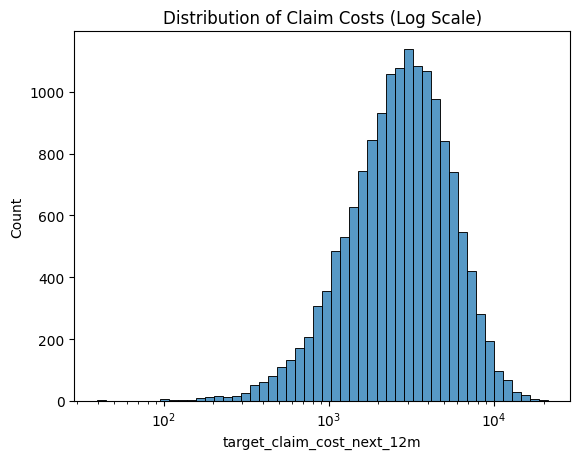

In [ ]:
sns.histplot(df['target_claim_cost_next_12m'], bins=50, log_scale=True)
plt.title("Distribution of Claim Costs (Log Scale)")
plt.show()

The 'Distribution of Claim Costs (Log Scale)' graph displays the frequency of different claim cost amounts, with the y-axis (count of policyholders) on a logarithmic scale. This log scale helps in visualizing a wide range of frequencies, particularly if there are many low-cost claims and fewer high-cost claims.

From the histogram, we can observe that:

Right-Skewed Distribution: Even with a log-scaled count, the distribution appears heavily right-skewed, meaning a large number of policyholders incur relatively low claim costs. This is typical for insurance claim data.
Concentration at Lower Costs: There is a high concentration of claims at the lower end of the cost spectrum, indicating that most claims are for smaller amounts.
Long Tail: The distribution has a 'long tail' extending to the right, signifying that while rare, some claims can be very expensive. These higher-cost claims, though less frequent, can significantly impact overall costs and risk.

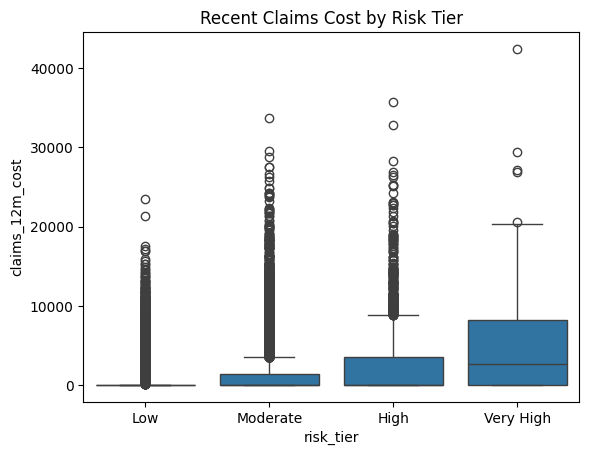

In [ ]:
sns.boxplot(
    x='risk_tier',
    y='claims_12m_cost',
    data=df,
    order=['Low','Moderate','High','Very High']
)
plt.title("Recent Claims Cost by Risk Tier")
plt.show()

The 'Recent Claims Cost by Risk Tier' box plot provides valuable insights from a business perspective:

Clear Risk Differentiation: There's a clear upward trend in claims_12m_cost as the risk_tier progresses from 'Low' to 'Very High'. This indicates that your risk tiering system is effective in categorizing policyholders based on their past claim expenditures, which is crucial for accurate risk assessment.
Pricing Strategy Validation: This strong correlation between risk tier and claim cost validates the basis for a differentiated pricing strategy. Policyholders in higher risk tiers should ideally be charged higher premiums to offset their anticipated higher claim costs.

Variability and Exposure: As the risk tier increases, not only do the median claim costs rise, but the spread (interquartile range and whiskers) of the costs also expands. This signifies greater variability and potential for higher individual claim amounts in the 'High' and 'Very High' tiers. This increased variability implies higher exposure for the insurer in these segments.

Outlier Management: The presence of outliers (individual points) further away from the main boxes, especially in higher risk tiers, highlights instances of exceptionally high-cost claims. Businesses need robust strategies to identify and manage these high-impact cases, potentially through specific underwriting rules or case management programs.

In essence, the plot confirms that risk_tier is a strong predictor of claim costs, underpinning the importance of accurate risk categorization for sustainable underwriting and profitability.

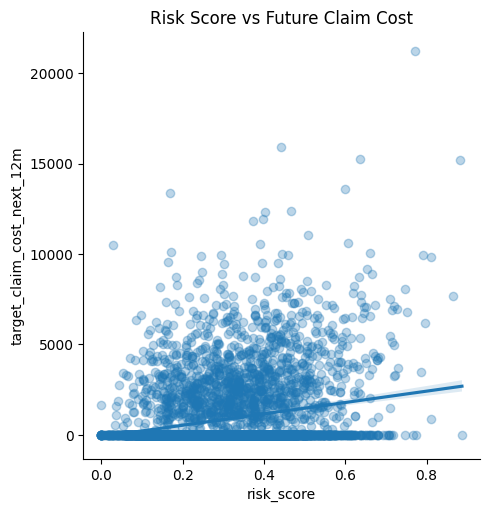

In [ ]:
sns.lmplot(
    x='risk_score',
    y='target_claim_cost_next_12m',
    data=df.sample(5000),
    scatter_kws={'alpha':0.3}
)
plt.title("Risk Score vs Future Claim Cost")
plt.show()

From a business perspective, here's what we can infer:

Positive Correlation: There appears to be a general positive correlation between risk_score and future claim cost. As the risk_score increases, there is a tendency for the target_claim_cost_next_12m to also increase. This suggests that the risk score is a valuable indicator for predicting future claim expenses.

Predictive Power: The scatter of points around the regression line (implied by lmplot) indicates that while the risk_score helps explain some of the variation in future claim costs, it is not a perfect predictor. There's still significant variability in claim costs even for similar risk scores, particularly at higher risk score values.

Segmentation Opportunity: The plot reinforces the idea that policyholders can be segmented based on their risk scores. Those with higher scores are more likely to incur higher future claim costs, which can inform differential pricing, proactive risk management interventions, and resource allocation.
Focus on High-Risk, High-Cost Cases: The scattered points with high target_claim_cost_next_12m values, especially among higher risk_score individuals, highlight the presence of costly claims. Understanding the drivers behind these high-cost cases is crucial for effective risk mitigation strategies.

In [ ]:
df.groupby('has_chronic')['target_claim_flag_next_12m'].mean()

,target_claim_flag_next_12m
has_chronic,
0,0.215360
1,0.306203


chronic conditions and future claim incidence:

Impact of Chronic Conditions: Policyholders who do not have chronic conditions (has_chronic = 0) have an average 12-month claim incidence rate of approximately 21.54%.
Increased Risk: In contrast, policyholders who do have chronic conditions (has_chronic = 1) have a significantly higher average 12-month claim incidence rate of approximately 30.62%.
From a business perspective, this means that the presence of chronic conditions is a strong indicator of increased risk for future claims. This information is crucial for:

Risk Assessment: It confirms that has_chronic is a valuable feature for identifying individuals with a higher likelihood of filing a claim.
Underwriting Decisions: This could influence underwriting rules, potentially leading to different policy terms or premiums for individuals with chronic conditions.

Targeted Interventions: It might also prompt consideration for proactive health management programs or support for policyholders with chronic conditions to help manage their health and potentially reduce future claim severity or frequency.

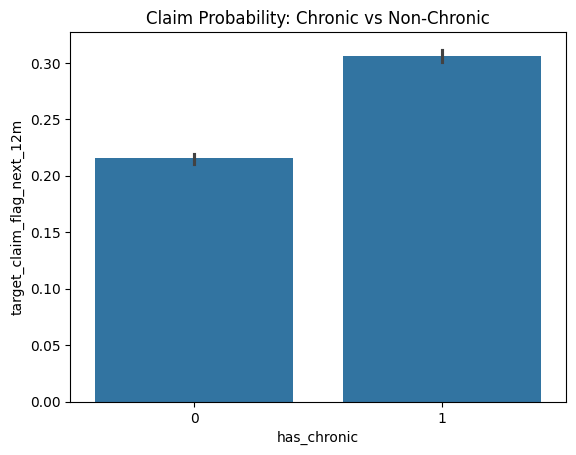

In [ ]:
sns.barplot(
    x='has_chronic',
    y='target_claim_flag_next_12m',
    data=df
)
plt.title("Claim Probability: Chronic vs Non-Chronic")
plt.show()

In [ ]:
chronic = df[df['has_chronic']==1]['target_claim_flag_next_12m']
non_chronic = df[df['has_chronic']==0]['target_claim_flag_next_12m']

t_stat, p_value = stats.ttest_ind(chronic, non_chronic, equal_var=False)
print(f"T-stat: {t_stat:.3f}, p-value: {p_value:.6f}")

T-stat: 25.235, p-value: 0.000000


Given the null hypothesis (H₀: Members with chronic conditions do not have higher claim probability) and the t-test results (T-stat: 25.235, p-value: 0.000000):

P-value (0.000000): This extremely small p-value (much less than common significance levels like 0.05 or 0.01) provides very strong evidence against the null hypothesis.

Conclusion: We reject the null hypothesis. This means there is statistically significant evidence to conclude that members with chronic conditions do have a higher claim probability than those without chronic conditions.

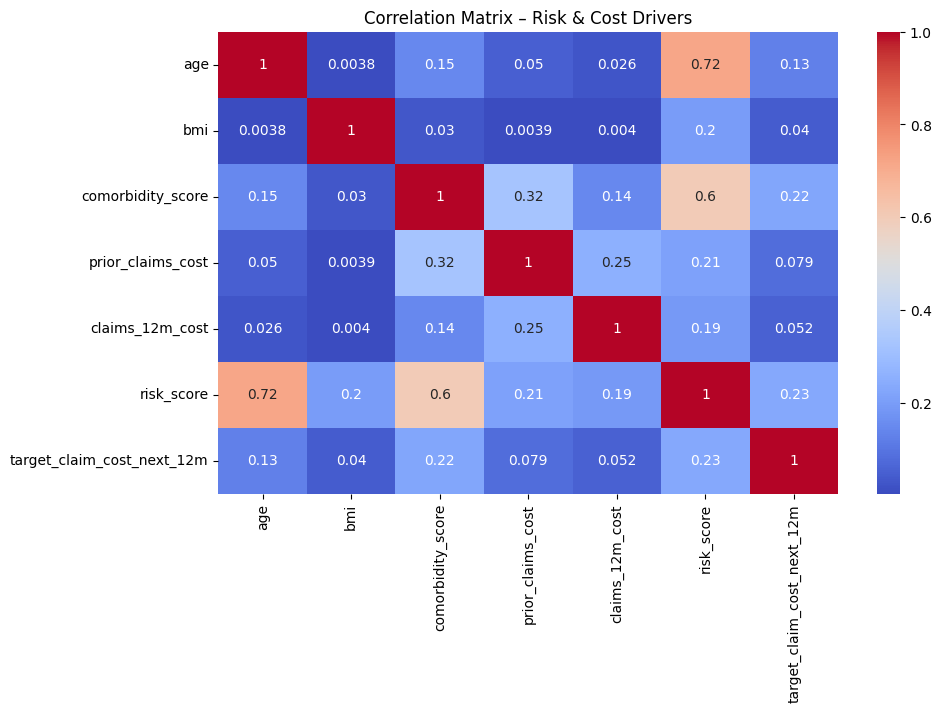

In [ ]:
num_cols = [
    'age','bmi','comorbidity_score','prior_claims_cost',
    'claims_12m_cost','risk_score','target_claim_cost_next_12m'
]

corr = df[num_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix – Risk & Cost Drivers")
plt.show()

From a business perspective, here's what we can observe:

Strong Positive Correlation between risk_score and age (0.72): This is a very significant finding. It suggests that as policyholders age, their calculated risk score tends to increase substantially. This implies that age is a major component or driver of the risk score, which is a common pattern in health and insurance risk modeling.
Positive Correlation with comorbidity_score and prior_claims_cost: Variables like comorbidity_score and prior_claims_cost also show positive correlations with risk_score and target_claim_cost_next_12m, though generally weaker than age. This indicates that a higher number of comorbidities and past claim expenses are associated with higher risk and future claim costs.
target_claim_cost_next_12m Relationships: The target_claim_cost_next_12m (our primary prediction target for regression) shows moderate positive correlations with risk_score, claims_12m_cost, prior_claims_cost, and comorbidity_score. This confirms that these are important drivers for predicting future claim costs.
Weak Correlations: Some variables, like bmi, show generally weak correlations with most other variables, suggesting it might not be as strong a linear predictor in isolation, or its impact could be more complex (e.g., non-linear or interactive).
Business Implications:

Risk Score Validation: The heatmap validates that the risk_score is well-aligned with other known risk factors like age and indicators of past utilization (prior_claims_cost, claims_12m_cost).
Feature Importance: It helps identify key features that are strongly correlated with target_claim_cost_next_12m, which are crucial for building predictive models. risk_score, claims_12m_cost, and prior_claims_cost stand out as significant linear predictors.
Underwriting Strategy: Understanding these correlations can help refine underwriting rules. For example, the strong link between age and risk score suggests that age-based adjustments or segments are well-founded.

Modeling – Claim Probability (Classification)

In [ ]:
target = 'target_claim_flag_next_12m'

num_features = [
    'age','bmi','deductible','annual_premium',
    'comorbidity_score','prior_claims_count',
    'prior_claims_cost','claims_12m_cost',
    'hospital_days_12m','in_network_ratio'
]

cat_features = [
    'gender','region','employer_size',
    'plan_type','smoking_status'
]

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)

Baseline Model (Logistic Regression)

In [ ]:
X = df[num_features + cat_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

clf = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

clf.fit(X_train, y_train)

y_pred_proba = clf.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

ROC-AUC: 0.6263025481312423


Production-Grade Model (Gradient Boosting)

In [ ]:
gbm = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3
    ))
])

gbm.fit(X_train, y_train)
y_pred_gbm = gbm.predict_proba(X_test)[:,1]

print("GBM ROC-AUC:", roc_auc_score(y_test, y_pred_gbm))


GBM ROC-AUC: 0.6261266985271899


Modeling – Claim Cost Severity (Regression)

In [ ]:
severity_df = df[df['target_claim_flag_next_12m']==1]

X_sev = severity_df[num_features + cat_features]
y_sev = severity_df['target_claim_cost_next_12m']

X_train, X_test, y_train, y_test = train_test_split(
    X_sev, y_sev, test_size=0.25, random_state=42
)

reg = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3
    ))
])

reg.fit(X_train, y_train)
pred = reg.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

MAE: 1586.7790125153158
RMSE: 2104.1801294637066


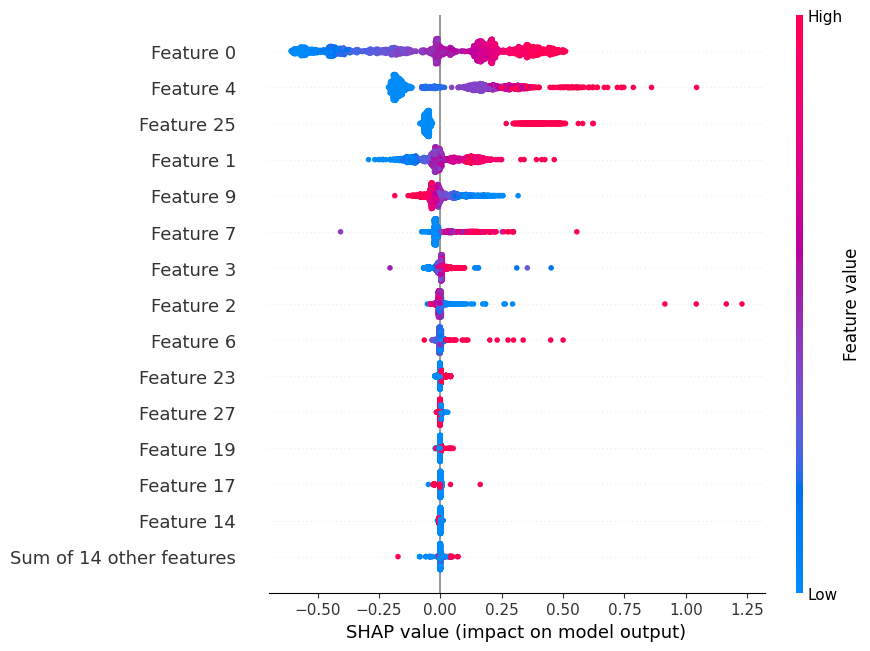

In [ ]:
explainer = shap.Explainer(gbm.named_steps['model'])
X_transformed = gbm.named_steps['prep'].transform(X_train[:2000])

shap_values = explainer(X_transformed)

shap.plots.beeswarm(shap_values, max_display=15)

In [ ]:
df['predicted_claim_risk'] = gbm.predict_proba(X)[:,1]

df[['policy_id','risk_score','predicted_claim_risk','risk_tier']].head(10)

,policy_id,risk_score,predicted_claim_risk,risk_tier
0,POL000000001,0.0737,0.124940,Low
1,POL000000002,0.2040,0.152274,Low
2,POL000000003,0.5677,0.412459,High
3,POL000000004,0.2080,0.158412,Low
4,POL000000005,0.4735,0.345792,Moderate
5,POL000000006,0.3765,0.301560,Moderate
6,POL000000007,0.3961,0.332733,Moderate
7,POL000000008,0.2528,0.257906,Moderate
8,POL000000009,0.3076,0.237787,Moderate
9,POL000000010,0.5658,0.462707,High
